# Analyzing Restaurant Booking Trends with Boosting Algorithms

## Context

Welcome to the Scaler Hospitality Analytics team! Our current initiative aims to enhance the booking management system for a chain of restaurants. Your expertise is requested to analyze the Restaurant Booking dataset, utilizing boosting algorithms to predict booking statuses and understand customer behaviors. This task will support strategic decision-making to optimize booking operations and enhance customer satisfaction.

Dataset Description
The dataset you will analyze contains a variety of attributes related to restaurant bookings. These details offer insights into customer preferences, booking patterns, and cancellation trends. Each booking record is characterized by several features:

Booking Attributes:
id: Unique identifier for each booking.
no_of_adults: Number of adults per booking.
no_of_children: Number of children per booking.
no_of_weekend_nights: Number of weekend nights booked.
no_of_week_nights: Number of weekday nights booked.
type_of_meal_plan: Type of meal plan selected (e.g., bed and breakfast, all-inclusive).
required_car_parking_space: Indicates if a parking space was required.
room_type_reserved: Type of room reserved.
lead_time: Number of days between the booking date and the arrival date.
arrival_year, arrival_month, arrival_date: Date details for when the booking is scheduled.
market_segment_type: The market segment from which the booking originated.
repeated_guest: Flag indicating if the guest has booked before.
no_of_previous_cancellations: Number of prior cancellations by the guest.
no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the guest.
avg_price_per_room: Average price per room type.
no_of_special_requests: Number of special requests made by the guest.
booking_status: Status of the booking ( confirmed = 0, canceled = 1).
Your objective is to use boosting techniques to predict the 'booking_status' and analyze factors that influence booking behaviors. This analysis will help in identifying key trends that could influence policy adjustments, promotional strategies, and operational improvements.

In [15]:
import urllib.request

url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/067/435/original/booking.csv"
urllib.request.urlretrieve(url, "booking.csv")

print("File downloaded successfully!")

File downloaded successfully!


In [16]:
import pandas as pd
df = pd.read_csv("booking.csv")
df_original = df.copy()
Target = "booking_status"
df.head()

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,0,2,0,0,2,1,0,0,9,2018,1,14,1,1,11,0,67.50,0,0
1,1,2,0,1,2,0,0,0,117,2018,7,29,0,0,0,0,72.25,0,0
2,2,2,0,0,1,0,0,0,315,2018,12,2,0,0,0,0,52.00,0,0
3,3,1,0,0,2,1,0,0,32,2018,12,1,1,0,0,0,56.00,0,0
4,4,2,0,1,0,0,0,0,258,2018,10,16,0,0,0,0,100.00,0,1


In [17]:
df.columns

Index(['id', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

In [18]:
X = df_original.drop(Target, axis=1)
y = df_original[Target]

df_original[Target].value_counts()

booking_status
0    25596
1    16504
Name: count, dtype: int64

# Assesments for Boosting 1

## Analyzing Restaurant Booking Patterns

Context:
Welcome to the Scaler Hospitality Analytics team! We're diving into the Restaurant Booking dataset to enhance our booking management system. Your insights will help us optimize operations and improve customer experiences.

Task:
Your initial task is to conduct an exploratory data analysis to uncover insights about unusual booking patterns, specifically, bookings where neither adults nor children are included.

Instructions:
Data Inspection: Examine the dataset for entries that indicate bookings with zero adults and zero children.
Count Such Bookings: Calculate the number of such instances to understand the prevalence of this anomaly.
Question:
Based on the dataset provided, how many bookings are recorded where both the number of adults and the number of children are zero?

In [19]:
booking_counts = df_original[(df_original['no_of_adults'] == 0) & (df_original['no_of_children'] == 0)].shape[0]
print("Number of bookings with zero adults and zero children:", booking_counts)

Number of bookings with zero adults and zero children: 16


## Booking Status Distribution by Month

Context:
Understanding seasonal trends in booking cancellations can help the Scaler Hospitality Analytics team develop targeted strategies to minimize losses and improve customer retention. You are tasked with visualizing how booking statuses vary by month.

Task:
Create a visual representation to analyze the distribution of booking cancellations across different months using the 'arrival_month' and 'booking_status' columns in the dataset.

Instructions:
Group and Count Data: Use the dataset to group entries by 'arrival_month' and 'booking_status'. Count the occurrences of each booking status (canceled or not canceled) for every month.
Visualize Data: Generate a bar chart that displays the counts of canceled and not canceled bookings for each month. This will help in visually comparing the booking trends over the year.
Analyze Trends: Examine the bar chart to determine which month has the highest number of cancellations and which has the lowest.
Question:
After analyzing the bar chart representing the booking status count for each month, identify the months with the highest and lowest number of booking cancellations.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

booking_status_counts = df_original.groupby(['arrival_month', 'booking_status']).size().unstack(fill_value = 0)

print(booking_status_counts)

booking_status     0     1
arrival_month             
1                747    58
2                884   317
3               1577   624
4               1924  1082
5               1955  1337
6               1945  1411
7               2463  2218
8               2722  3041
9               2981  2167
10              3530  2923
11              2029   774
12              2839   552


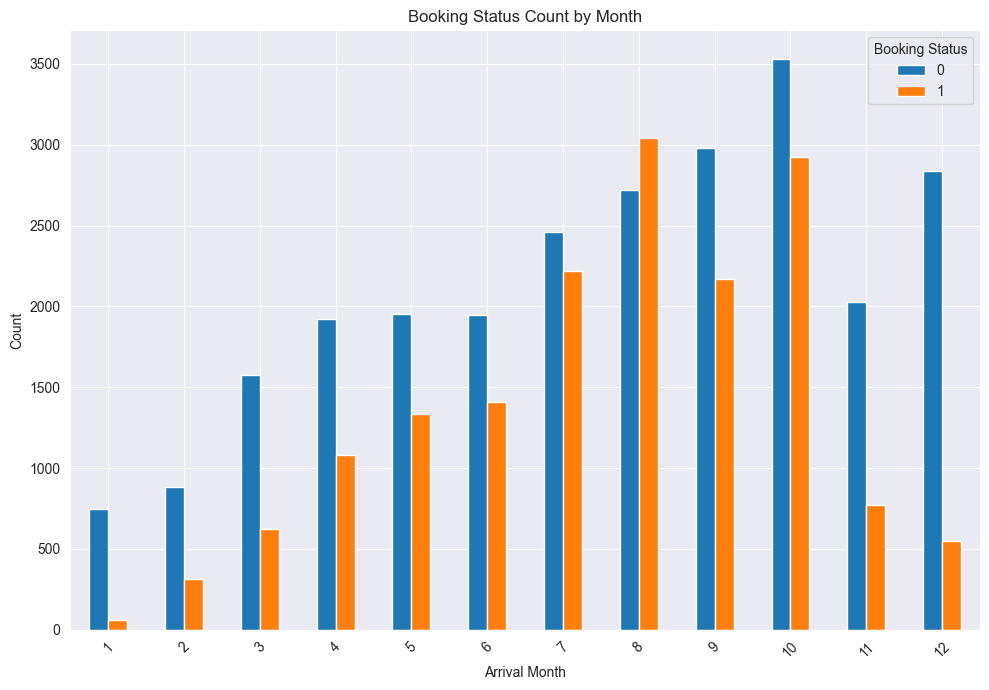

In [21]:
booking_status_counts.plot(kind = 'bar', figsize = (10,7))

plt.title('Booking Status Count by Month')
plt.xlabel('Arrival Month')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.legend(title = 'Booking Status')
plt.tight_layout()
plt.show()

## Data Engineering

Context:
Effective date engineering can uncover deeper insights in time-series data such as hotel bookings. This task involves transforming basic date-related columns into a comprehensive set of datetime features that can be used for advanced analysis and model building.

Task:
Develop a Python function named process_arrival_date that converts basic date fields in a hotel booking dataset into a rich set of datetime features. This function should handle data transformation and cleanup efficiently.

Function Requirements:
Input and Output: The function should accept a DataFrame and return a modified DataFrame with new datetime-related features.
Rename Columns: Change 'arrival_year', 'arrival_month', and 'arrival_date' to 'year', 'month', and 'day'.
Create Datetime Column: Combine 'year', 'month', and 'day' into a new 'date' column as a datetime object. Use pd.to_datetime with errors='coerce' to handle any data inconsistencies.
Extract Datetime Features: From the 'date' column, derive and add new columns such as 'year', 'month', 'week', 'day', 'dayofweek', 'quarter', and 'dayofyear'.
Cleanup: Remove any intermediate columns like the temporary 'date' column after extracting necessary features.
Instructions:
Define the Function: Implement the process_arrival_date function based on the above requirements.
Apply the Function: Test the functionality of your function by applying it to a DataFrame df.
Verify Output: Check the resulting DataFrame to ensure it includes all new date-related features and excludes any redundant or temporary columns.
Question:
After applying the process_arrival_date function to a DataFrame and transforming the date-related columns, what are the number of missing values (NaN) in the newly created columns?

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

def process_arrival_date(data):
    data.drop(columns = ['year', 'month', 'day'], inplace = True, errors = 'ignore')

    temp = data.rename(columns = {
        'arrival_year': 'year',
        'arrival_month' : 'month',
        'arrival_date' : 'day'
    })

    data['date'] = pd.to_datetime(temp[['year', 'month', 'day']], errors = 'coerce')

    data['year'] = data['date'].dt.year
    data['month'] = data['date'].dt.month
    data['week'] = data['date'].dt.isocalendar().week.astype(float)
    data['day'] = data['date'].dt.day
    data['dayofweek'] = data['date'].dt.dayofweek
    data['quarter'] = data['date'].dt.quarter
    data['dayofyear'] = data['date'].dt.dayofyear

    data.drop(columns = ['date'], inplace = True)
    return data
new_processed_df = process_arrival_date(df)

missing_values = new_processed_df.isna().sum()
print(missing_values)

id                                       0
no_of_adults                             0
no_of_children                           0
no_of_weekend_nights                     0
no_of_week_nights                        0
type_of_meal_plan                        0
required_car_parking_space               0
room_type_reserved                       0
lead_time                                0
arrival_year                             0
arrival_month                            0
arrival_date                             0
market_segment_type                      0
repeated_guest                           0
no_of_previous_cancellations             0
no_of_previous_bookings_not_canceled     0
avg_price_per_room                       0
no_of_special_requests                   0
booking_status                           0
year                                    50
month                                   50
week                                    50
day                                     50
dayofweek  

## Sequencing Steps in Boosting Algorithm

Sequencing Steps in Boosting Algorithm
Context:
Boosting is a powerful ensemble machine learning technique that combines multiple weak learners to form a strong predictive model. Each learner is sequentially added, specifically focusing on the errors of the previous models.

Task:
Organize the steps involved in the implementation of a boosting algorithm. This will test your understanding of the sequential nature of how boosting models are constructed and optimized.

Question
Consider the key points listed about the boosting algorithm process. Put the following steps in the correct order, from first to last, as they would occur in the implementation of a boosting algorithm. <br

Steps to Sequence:
Sequential Model Development
Base Learner Initialization
Initiation with a Preliminary Model
Combination through Addition
Prediction Weight Adjustment
Options
A] 2, 3, 1, 4, 5

B] 3, 2, 1, 5, 4 (Correct One)

C] 2, 3, 4, 1, 5

D] 3, 1, 2, 5, 4

## Simple Boosting Algorithm

Context:
Boosting is an ensemble technique that combines multiple weak learners to create a strong classifier. Each weak learner is trained sequentially, with each one focusing on the errors made by the previous models.

Task:
Complete the Python code provided to implement a simple boosting algorithm using two Decision Tree classifiers. Then, determine the accuracy of the combined model.

Instructions:
Fill in the Blanks: Complete the Python code where indicated (blanks marked with __1__, __2__, __3__, and __4__) to ensure the boosting algorithm functions correctly.
Run the Code: Execute the completed code on your dataset to train the Decision Trees and combine their predictions.
Verify and Analyze Results: Calculate the accuracy of the final combined prediction and select the correct answer based on the output.
Note: Target = 'booking_status', y = df[Target] and X = df.drop(Target, axis = 1)

Question:
After implementing the described boosting process and running the complete code, what is the accuracy of the final combined predictions?

In [23]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

weights = np.ones(len(X)) / len(X)

dt1 = DecisionTreeClassifier(random_state = 10, max_depth = 1)
dt1.fit(X, y)
y_pred_1 = dt1.predict(X)

def update_weights(y, y_pred, weights):
    for i in range(len(weights)):
        if y[i] != y_pred[i]:
            weights[i] *= 1.5
        else:
            weights[i] *= 0.5
    return weights / np.sum(weights)

weights = update_weights(y, y_pred_1, weights)

dt2 = DecisionTreeClassifier(random_state = 10, max_depth = 1)
dt2.fit(X, y, sample_weight = weights)
y_pred_2 = dt2.predict(X)

final_prediction = np.round((y_pred_1 + y_pred_2) / 2.0).astype(int)
final_accuracy = accuracy_score(y, final_prediction)

print(f"Final combined prediction accuracy: {final_accuracy}")

Final combined prediction accuracy: 0.7140380047505939


## Boosting Step Residual

Context:
Gradient Boosting is an advanced boosting technique that builds models sequentially, each new model correcting errors made by the previous ones. A key component of Gradient Boosting involves the use of pseudo residuals to guide the learning of subsequent models.

Task:
Organize the steps involved in using pseudo residuals within a Gradient Boosting framework. This task will test your understanding of the methodical process through which boosting models iteratively enhance their accuracy.

Steps:
Train a new learner on the pseudo residuals.
Calculate pseudo residuals based on the loss function's derivative.
Initialize the model with a simple estimator (e.g., the mean of the target variable).
Update the model by adding the new learner, scaled by the learning rate.
Evaluate the current model and calculate the loss for each instance.
Question
Arrange the following steps to reflect how pseudo residuals are used in the iterative process of boosting.

Options:

A. 3, 5, 2, 1, 4

B. 5, 2, 1, 3, 4

C. 2, 3, 1, 4, 5

D. 3, 1, 5, 2, 4 (Correct)

## Code Boosting Residual

Context:
Gradient Boosting is a sequential learning technique in regression and classification that builds models progressively, using an ensemble of weak prediction models like decision trees. It focuses on minimizing errors primarily through the use of pseudo residuals.

Task:
Complete the Python code provided below to implement a simple gradient boosting algorithm using pseudo residuals. You will fill in the missing parts of the code, run it, and determine the model's accuracy using mean squared error.

Instructions:
Fill in the Blanks: Complete the Python code where indicated (blanks marked with __1__, __2__, __3__, and __4__) to ensure the boosting algorithm functions correctly.
Run the Code: Execute the completed code on your dataset to train the Decision Tree regressors and update the model predictions.
Verify and Analyze Results: Calculate the final model accuracy using the mean squared error and select the correct accuracy from the given options.
Question:
After filling in the blanks and executing the code, what is the final model accuracy based on the mean squared error?

In [24]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

y_pred = np.full(shape = y.shape, fill_value = np.mean(y))

pseudo_residuals = y - y_pred

learning_rate = 0.1

dt1 = DecisionTreeRegressor(max_depth = 1, random_state = 10)
dt1.fit(X, pseudo_residuals)
y_pred_1 = dt1.predict(X)

y_pred += y_pred_1 * learning_rate

pseudo_residuals = y - y_pred

dt2 = DecisionTreeRegressor(max_depth = 1, random_state = 10)
dt2.fit(X, pseudo_residuals)
y_pred_2 = dt2.predict(X)

y_pred += y_pred_2 * learning_rate

final_accuracy = 1 - mean_squared_error(y, y_pred)
print(f"Final model accuracy: {final_accuracy}")

Final model accuracy: 0.7740567736555297


## Comparing Gradient Boosting Performance

Context:
Effectively preprocessing data can significantly impact the performance of machine learning models. This task involves evaluating how a Gradient Boosting Classifier performs on both an original dataset and the same dataset after preprocessing and missing value removal.

Task:
Implement a Gradient Boosting Classifier and assess its accuracy on both the original and a preprocessed version of a dataset. This will help determine the impact of preprocessing on model performance.

Instructions:
Split Original Data: Use train_test_split to divide the original dataset (df) into training and test sets, setting test_size to 0.2 and random_state to 10.
Train on Original Data: Fit a GradientBoostingClassifier on the original training data and evaluate its accuracy on the original test set.
Preprocess the Dataset: Apply the process_arrival_date function and remove rows with missing values to create a cleaned dataset (new_processed_df).
Split Preprocessed Data: Split the preprocessed dataset (new_processed_df) into training and test sets, again with a test_size of 0.2 and random_state to 10.
Train on Preprocessed Data: Train a new GradientBoostingClassifier on the preprocessed training data and evaluate its accuracy on the preprocessed test set.
Compare Accuracies: Assess whether the model's accuracy improved, declined, or remained the same after preprocessing.
Question:
After implementing the Gradient Boosting Classifier and comparing its performance on both the original and the preprocessed datasets, which statement accurately describes the change in accuracy?

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size = 0.2, random_state = 10)

gbc_orig = GradientBoostingClassifier(random_state = 10)
gbc_orig.fit(X_train_orig, y_train_orig)
pred_orig = gbc_orig.predict(X_test_orig)
accuracy_orig = accuracy_score(y_test_orig, pred_orig)

new_df = new_processed_df.dropna()

X_train_proc, X_test_proc, y_train_proc, y_test_proc = train_test_split(
    new_processed_df.drop('booking_status', axis = 1),
    new_processed_df['booking_status'],
    test_size = 0.2,
    random_state = 10
)

gbc_proc = GradientBoostingClassifier(random_state = 10)
gbc_proc.fit(X_train_proc, y_train_proc)
pred_proc = gbc_proc.predict(X_test_proc)
accuracy_proc = accuracy_score(y_test_proc, pred_proc)

print(f"Accuracy on original data: {accuracy_orig}")
print(f"Accuracy on processed data: {accuracy_proc}")

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# Boosting - 2

## GBD Feature Importance

Context:
Feature importance is a vital concept in machine learning, allowing data scientists to understand better which features contribute most to a model's predictions. Using a Gradient Boosting Classifier, this task focuses on determining the most influential feature in a dataset.

Task:
Train a Gradient Boosting Classifier on a given dataset and analyze the model to identify which feature is considered the most important based on the trained model.

Instructions:
Split the Data: Use train_test_split to divide the dataset into training and test sets with a test_size of 0.2 and random_state of 10.
Train the Model: Fit a GradientBoostingClassifier with default parameters on the training data. Ensure random_state is set to 10 for reproducibility.
Extract Feature Importance: After training, use the model's feature_importances_ attribute to determine the significance of each feature.
Identify the Most Important Feature: Determine which feature has the highest importance score.
Question:
After training the Gradient Boosting Classifier and examining the feature importance scores, which feature is considered most important?

The most important feature is: lead_time


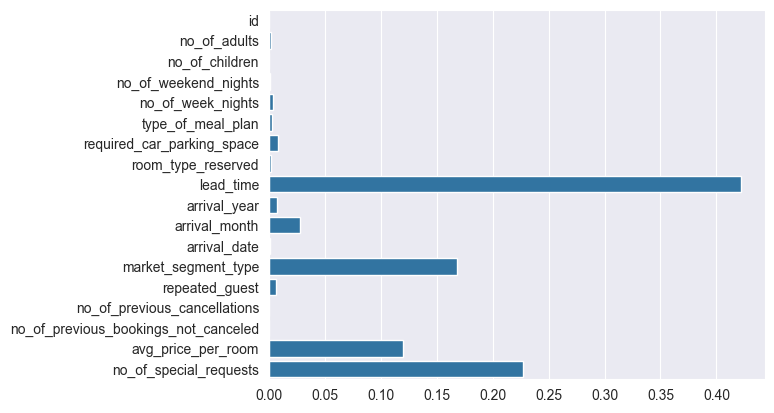

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

clf = GradientBoostingClassifier(random_state = 10)
clf.fit(X_train, y_train)

feature_importances = clf.feature_importances_

features = np.array(X.columns)

most_important_feature = features[np.argmax(feature_importances)]

print(f"The most important feature is: {most_important_feature}")

sns.barplot(y=features, x=feature_importances)
plt.show()

## Optimizing Learning Rate

Context:
The learning rate in gradient boosting models is a crucial parameter that scales the contribution of each tree. It can significantly affect model performance by controlling how quickly the model adapts to the complex underlying patterns in the data.

Task:
Your task is to find the optimal learning rate for a Gradient Boosting Classifier applied to the Reservation Cancellation Dataset. This involves comparing the performance of models trained with different learning rates.

Instructions:
Split the Data: Use train_test_split to divide the dataset into training and test sets, setting test_size to 0.2 and random_state to 10.
Define Learning Rates: Test the classifier's performance across a range of learning rates: {0.1, 0.05, 0.01, 0.005, 0.001}.
Train and Evaluate Models: For each learning rate, train a GradientBoostingClassifier and evaluate its accuracy on the test set.
Determine Optimal Learning Rate: Identify the learning rate that results in the highest accuracy.
Question:
After evaluating Gradient Boosting Classifier models with different learning rates on the Reservation Cancellation Dataset, which learning rate yielded the highest accuracy on the test set?

In [27]:
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001]
best_accuracy = 0
best_learning_rate = 0

for lr in learning_rates:
    model = GradientBoostingClassifier(learning_rate = lr, random_state = 10)
    model.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test))
    print(lr, " : ", accuracy)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_learning_rate = lr

print(f"The best learning rate is: {best_learning_rate} with an accuracy of: {best_accuracy}")

0.1  :  0.8042755344418052
0.05  :  0.8005938242280285
0.01  :  0.7859857482185273
0.005  :  0.7357482185273159
0.001  :  0.6086698337292161
The best learning rate is: 0.1 with an accuracy of: 0.8042755344418052


## Boosting Max Depth

Context:
The max_depth parameter in Gradient Boosting Classifier determines the maximum depth of the individual trees. Adjusting this parameter affects the model's complexity and its ability to capture the underlying patterns in the data, thus influencing performance.

Task:
Your task is to identify the optimal max_depth value that results in the highest accuracy for a Gradient Boosting Classifier applied to a dataset. This involves training and evaluating the classifier at various tree depths.

Instructions:
Prepare Data: Split the dataset into training and test sets using train_test_split, with a test_size of 0.2 and random_state of 10. Separate the dataset into X (features) and y (target).
Define Depth Range: Test the classifier's performance across a range of depths from 1 to 15.
Train and Evaluate Models: For each depth value, train a GradientBoostingClassifier and evaluate its accuracy on the test set.
Determine Optimal Depth: Identify the depth that results in the highest accuracy.
Question:
After training the Gradient Boosting Classifier at different tree depths and evaluating the models, which max_depth resulted in the highest accuracy on the test set?

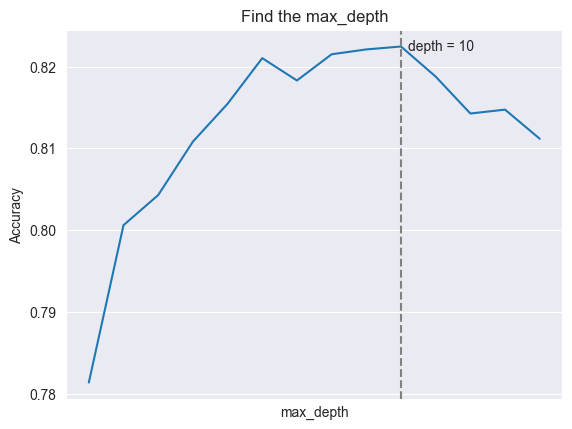

In [28]:
acc = []
best_depth = 0
best_acc = 0

for d in range(1, 15):
    model = GradientBoostingClassifier(max_depth=d, random_state = 10)
    model.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test))
    acc.append(accuracy)

    if accuracy > best_acc:
        best_acc = accuracy
        best_depth = d

sns.lineplot(x=range(1,15), y=acc)

plt.xticks([])

plt.title("Find the max_depth")
plt.xlabel('max_depth')
plt.ylabel('Accuracy')

highest_acc = acc[best_depth - 1]
plt.axvline(x = best_depth, color = 'grey', linestyle = '--')
plt.text(best_depth + 0.2, highest_acc, f"depth = {best_depth}", verticalalignment='center')

plt.show()

## Impact of Feature Scaling

Context:
Feature scaling can significantly influence the performance of many machine learning algorithms, particularly those that are distance-based. However, decision trees and their ensembles (like Gradient Boosting) typically do not require feature scaling to perform effectively since they are not sensitive to the scale of the data.

Task:
Investigate whether scaling affects the performance of a Gradient Boosting Classifier by training two models: one with scaled features and one with original features.

Instructions:
Prepare Data: Split the dataset into X (features) and y (target). Then use train_test_split to divide the data into training and test sets, setting test_size to 0.2 and random_state to 10.
Scale Features: Apply StandardScaler to scale X_train and X_test for the first model.
Train Models: Train two Gradient Boosting Classifiers—one on the scaled training data and the other on the original training data. Ensure both models use random_state=10.
Evaluate Models: Calculate the accuracy of both models on their respective test sets.
Compare Accuracies: Calculate the difference in accuracy between the scaled and the unscaled model.
Question:
After training and evaluating both models, what will be the output of accuracy_with_scaled_data - accuracy_without_scaled_data?

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

model_with_scaled = GradientBoostingClassifier(random_state = 10)
model_with_scaled.fit(X_train_scaled, y_train)
accuracy_with_scaled = accuracy_score(y_test, model_with_scaled.predict(X_test_scaled))

model_without_scaled = GradientBoostingClassifier(random_state = 10)
model_without_scaled.fit(X_train_scaled, y_train)
accuracy_without_scaled = accuracy_score(y_test, model_without_scaled.predict(X_test_scaled))

print(f"accuracy_with_scaled = {accuracy_with_scaled}")
print(f"accuracy_without_scaled = {accuracy_without_scaled}")

print(f"Difference in accuracy = {accuracy_with_scaled - accuracy_without_scaled}")

accuracy_with_scaled = 0.8042755344418052
accuracy_without_scaled = 0.8042755344418052
Difference in accuracy = 0.0


## Hyperparameter Tuning with Grid Search

Context:
Hyperparameter tuning is a critical step in optimizing machine learning models. Using GridSearchCV, you will tune the hyperparameters of a Gradient Boosting Classifier to find the combination that achieves the best performance on a given dataset.

Task:
Apply GridSearchCV to optimize a Gradient Boosting Classifier's hyperparameters on a split dataset. Determine the set of hyperparameters that results in the highest cross-validation performance.

Instructions:
Split the Data: Use train_test_split to divide the dataset into training and test sets, with a test_size of 0.2 and random_state of 10.
Set Up GridSearchCV: Configure GridSearchCV with the Gradient Boosting Classifier, specifying the hyperparameter grid and setting cv=2 for cross-validation.
Define the Hyperparameter Grid: Use the given parameter grid to explore different configurations.
Train and Evaluate: Execute the GridSearchCV to find the best hyperparameters based on cross-validation performance.
Report Optimal Hyperparameters: Identify and report the hyperparameters that led to the best model performance.

Question:
After conducting the grid search, what are the optimal hyperparameters (Rank 1 parameters) discovered for the Gradient Boosting Classifier?

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5,8],
    'min_samples_split': [2,4, 6]
}

gbm = GradientBoostingClassifier(random_state = 10)

grid_search = GridSearchCV(gbm, param_grid, scoring = 'accuracy', cv = 2, n_jobs = -1, verbose = 1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

result = grid_search.cv_results_

for i in range(len(result['params'])):
    print(f"Parameters: {result['params'][i]} Mean_score: {result['mean_test_score'][i]} Rank: {result['mean_test_score'][i]}")

print(grid_search.best_estimator_)

Fitting 2 folds for each of 18 candidates, totalling 36 fits
Best parameters: {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 300}
Best cross-validation score: 0.8178741092636579
Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} Mean_score: 0.8135391923990498 Rank: 0.8135391923990498
Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} Mean_score: 0.8164489311163896 Rank: 0.8164489311163896
Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300} Mean_score: 0.8168052256532067 Rank: 0.8168052256532067
Parameters: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 100} Mean_score: 0.8133610451306413 Rank: 0.8133610451306413
Parameters: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 200} Mean_score: 0.8174881235154394 Rank: 0.8174881235154394
Parameters: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 300} Mean_score: 0.8175771971496437 Rank: 0.8175771971496437
Parameters: {'max_depth': 5, 'mi

## Top Ranked Parameters

Context:
After optimizing the parameters for a Gradient Boosting Classifier using GridSearchCV, it's crucial to validate the effectiveness of these parameters beyond just cross-validation scores, specifically on a held-out test set.

Task:
Train multiple Gradient Boosting Classifier models using the top 5 ranked parameter sets from a previous GridSearchCV optimization. Evaluate each model's performance on a separate test set to determine which set achieves the highest accuracy.

Instructions:
Train Models with Top 5 Parameters: Using the results from the previous GridSearchCV, identify the top 5 parameter sets based on cross-validation scores. Train a new model for each of these parameter sets on the training data.
Evaluate on Test Set: Assess the performance of each model on the test set using accuracy as the metric.
Rank the Test Accuracies: Determine the rank of each model based on test set accuracy, identifying which parameter set performed best.
Question:
After evaluating the test set accuracies for Gradient Boosting Classifiers trained with the top 5 parameter sets, what is the rank of the best performing model?

In [34]:
sorted_indices = np.argsort(result['rank_test_score'])
top_indices = sorted_indices[:5]

for i in top_indices:
    params = result['params'][i]
    print(f"Training model number {i} with parameters: {params}")

    model = GradientBoostingClassifier(**params, random_state = 10)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"Test Score with parameters {params}: {score}\n")

Training model number 8 with parameters: {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 300}
Test Score with parameters {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 300}: 0.8242280285035629

Training model number 5 with parameters: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 300}
Test Score with parameters {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 300}: 0.8243467933491686

Training model number 4 with parameters: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 200}
Test Score with parameters {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 200}: 0.8201900237529691

Training model number 7 with parameters: {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 200}
Test Score with parameters {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 200}: 0.8207838479809976

Training model number 2 with parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Test Score with parameters {'max_depth': 5, '

## Identifying Outliers

Context:
Outliers can significantly influence the performance of machine learning models, especially those not robust to extreme variations. Identifying outliers in training data helps in understanding their potential impact and deciding whether they should be treated or left as is.

Task:
Determine the number of outliers in the 'lead_time' feature of the training dataset, based on specified percentile thresholds.

Instructions:
Split the Data: Use train_test_split to divide the dataset into training and test sets, setting test_size to 0.2 and random_state to 10.
Identify Outliers: Calculate the 1st and 99th percentiles for the 'lead_time' feature in the training data and count how many values fall outside this range.
Count Outliers: Determine the total number of outliers based on these thresholds.
Question:
Based on the 'lead_time' feature, how many outliers are present in the X_train set after splitting the dataset?

In [35]:
low_threshold, high_threshold = np.percentile(X_train['lead_time'], [1,99])

not_outliers = X_train['lead_time'].between(low_threshold, high_threshold)

num_outliers = np.sum(~not_outliers)
print(f"Number of outliers: {num_outliers}")

Number of outliers: 334


## Impact of Outlier Removal

Context:
Outlier removal can potentially improve the performance of machine learning models by reducing noise and anomalies that can mislead the training process. This task involves assessing the effect of outlier removal on the accuracy of a Gradient Boosting Classifier.

Task:
Train a Gradient Boosting Classifier on a dataset from which outliers have been removed and compare its performance with a model trained on the original dataset.

Steps:
Prepare and Clean Data: Remove outliers from X_train based on the 'lead_time' feature using previously identified thresholds. Assume outliers have been identified using the 1st and 99th percentiles.
Train Models:
Train a model on the dataset with outliers removed.
Train another model on the original dataset for comparison.
Evaluate Models: Assess both models' performance using accuracy on X_test.
Compare Performances: Analyze whether removing outliers improves, reduces, or has no impact on model accuracy.
Question:
After removing outliers based on the 'lead_time' feature and training a new Gradient Boosting Classifier, what is the impact on the model's accuracy when evaluated on X_test?

In [36]:
original_clf = GradientBoostingClassifier(random_state = 10)
original_clf.fit(X_train, y_train)
original_prediction = original_clf.predict(X_test)
original_accuracy = accuracy_score(y_test, original_prediction)
print(f"Original dataset accuracy: {original_accuracy}")

lead_time_low = np.percentile(X_train['lead_time'], 1)
lead_time_high = np.percentile(X_train['lead_time'], 99)
mask = X_train['lead_time'].between(lead_time_low, lead_time_high)

X_train_no_outliers = X_train[mask]
y_train_no_outliers = y_train[mask]

if len(X_train_no_outliers) == 0:
    print("No data left after removing outliers based on 'lead_time'. Consider adjusting the percentile thresholds.")
else:
    clf_no_outliers = GradientBoostingClassifier(random_state = 10)
    clf_no_outliers.fit(X_train_no_outliers, y_train_no_outliers)
    no_outluers_predictions = clf_no_outliers.predict(X_test)
    no_outliers_accuracy = accuracy_score(y_test, no_outluers_predictions)
    print(f"Dataset without outliers (based on 'lead_time') accuracy: {no_outliers_accuracy}")

    if no_outliers_accuracy > original_accuracy:
        print("Removing outliers based on 'lead_time' improved the model's accuracy.")
    else:
        print("Removing outliers based on 'lead_time' did not improve the model's accuracy.")

Original dataset accuracy: 0.8042755344418052
Dataset without outliers (based on 'lead_time') accuracy: 0.8065320665083135
Removing outliers based on 'lead_time' improved the model's accuracy.


## Comparing Loss Functions

Context:
The choice of loss function in a Gradient Boosting Classifier can influence its performance. Typically, "log loss" is used for classification, but "exponential" loss, which leads to a model similar to AdaBoost, can also be used.

Task:
Evaluate the performance impact of different loss functions in a Gradient Boosting Classifier. Train two versions of the classifier on the same dataset: one using the default "log loss" loss function and another using the "exponential" loss function, then compare their accuracies.

Instructions:
Prepare Data: Split the dataset into training and test sets using train_test_split, setting test_size to 0.2 and random_state to 10.
Train with Default Loss Function:
Train a Gradient Boosting Classifier using the default "log loss" loss function.
Evaluate its accuracy on X_test.
Train with Exponential Loss Function:
Train another Gradient Boosting Classifier, setting the loss parameter to "exponential".
Evaluate its accuracy on X_test.
Compare Performances: Assess whether the model using "exponential" loss achieves higher, lower, or the same accuracy as the model using "log loss" loss.
Question:
How does the accuracy of the Gradient Boosting Classifier using the exponential loss function compare to the model using the default log_loss function when evaluated on X_test?

In [37]:
clf_log_loss = GradientBoostingClassifier(loss = 'log_loss', random_state = 10)
clf_log_loss.fit(X_train, y_train)
predictions_log_loss = clf_log_loss.predict(X_test)
accuracy_log_loss = accuracy_score(y_test, predictions_log_loss)
print(f"Accuracy with the 'exponential' loss function: {accuracy_log_loss}")

clf_exponential = GradientBoostingClassifier(loss = 'exponential', random_state = 10)
clf_exponential.fit(X_train, y_train)
predictions_exponential = clf_exponential.predict(X_test)
accuracy_exponential = accuracy_score(y_test, predictions_exponential)
print(f"Accuracy with the 'exponential' loss function: {accuracy_exponential}")

if accuracy_exponential > accuracy_log_loss:
    print("The 'exponential' loss function model is more accurate on the test set.")
elif accuracy_exponential < accuracy_log_loss:
    print("The 'log_loss' loss function model is more accurate on the test set.")
else:
    print("Both models have the same accuracy on the test set")

Accuracy with the 'exponential' loss function: 0.8042755344418052
Accuracy with the 'exponential' loss function: 0.8057007125890736
The 'exponential' loss function model is more accurate on the test set.


## Evaluating the Impact of Increasing Weak Learners

Context:
In Gradient Boosting, the number of weak learners (trees) is a crucial hyperparameter. It controls the complexity of the model and can significantly impact its performance. Observing how the model's accuracy evolves with the addition of more trees can provide insights into its learning dynamics and potential overfitting.

Task:
Train a series of Gradient Boosting Classifiers with an increasing number of estimators to evaluate how the addition of trees affects the test accuracy on a given dataset.

Instructions:
Prepare Data: Split the dataset into training and test sets using train_test_split, setting test_size to 0.2 and random_state to 10.
Initialize and Train Models:
Start with a Gradient Boosting Classifier with n_estimators=1.
Incrementally increase n_estimators through the set [1, 5, 10, 20, 50, 100, 200, 300, 500, 1000], training a new model at each step.
Evaluate Each Model: Assess the accuracy of each model on X_test.
Record and Analyze Results: Track how the test accuracy changes as more estimators are added. Look for trends such as increases, plateaus, or potential decreases in accuracy which could suggest overfitting.
Question:
How does the addition of more weak learners (trees) affect the test accuracy of the Gradient Boosting Classifier?

Accuracy with 1 estimators: 0.8042755344418052
Accuracy with 5 estimators: 0.8042755344418052
Accuracy with 10 estimators: 0.8042755344418052
Accuracy with 20 estimators: 0.8042755344418052
Accuracy with 50 estimators: 0.8042755344418052
Accuracy with 100 estimators: 0.8042755344418052
Accuracy with 200 estimators: 0.8042755344418052
Accuracy with 300 estimators: 0.8042755344418052
Accuracy with 500 estimators: 0.8042755344418052
Accuracy with 1000 estimators: 0.8042755344418052


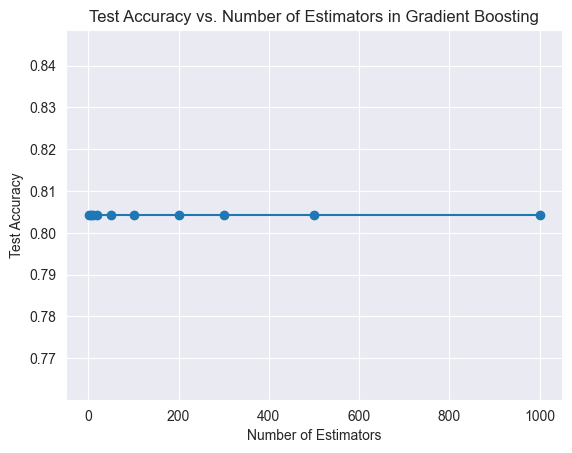

In [38]:
n_estimators_list = [1, 5, 10, 20, 50, 100, 200, 300, 500, 1000]
test_accuracies = []

for n_estimators in n_estimators_list:
    clf = GradientBoostingClassifier(random_state = 10)
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    test_accuracies.append(accuracy)
    print(f"Accuracy with {n_estimators} estimators: {accuracy}")

plt.plot(n_estimators_list, test_accuracies, marker = 'o')
plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy vs. Number of Estimators in Gradient Boosting')
plt.grid(True)
plt.show()

# Other Boosting Techniques

## Comparison Between XGBoost and GBC

Context:
XGBoost and Gradient Boosting Classifier (GBC) are both powerful ensemble machine learning algorithms based on boosting. While both aim to sequentially correct errors of weak learners, they are implemented differently and may have variations in performance, training speed, and memory usage.

Task:
Train both an XGBoost model and a Gradient Boosting Classifier on a dataset, then compare their training time and the file sizes of the saved models to determine which model is more efficient in terms of speed and storage.

Instructions:
Split the Data: Use train_test_split to divide the dataset into training and test sets, with a test_size of 0.2 and random_state of 10.
Train Models:
Train an XGBoost model using default parameters.
Train a Gradient Boosting Classifier using default parameters.
Record the training time for each model.
Serialize Models:
Save both models to disk using pickle.
Record the file size of each saved model.
Evaluate and Compare:
Compare the training times and file sizes to determine which model is more efficient.
Question:
After performing the training and saving the models, which of the following statements is correct regarding the performance and efficiency of XGBoost and GBC?

In [42]:
import time
import pickle
from xgboost import XGBClassifier
import os

start_time = time.time()
xgb_model = XGBClassifier(random_state = 10)
xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time

with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

start_time = time.time()
gbc_model = GradientBoostingClassifier(random_state = 10)
gbc_model.fit(X_train, y_train)
gbc_train_time = time.time() - start_time

with open('gbc_model.pkl', 'wb') as file:
    pickle.dump(gbc_model, file)

print(f"XGBoost training time: {xgb_train_time} seconds")
print(f"GBC training time: {gbc_train_time} seconds")

xgb_file_size = os.path.getsize('xgb_model.pkl')
gbc_file_size = os.path.getsize('gbc_model.pkl')

print(f"XGBoost model file size: {xgb_file_size} bytes")
print(f"GBC model file size: {gbc_file_size} bytes")

XGBoost training time: 0.48462605476379395 seconds
GBC training time: 6.422393798828125 seconds
XGBoost model file size: 377194 bytes
GBC model file size: 139292 bytes


## Comparing Feature Importance

Context:
Understanding how different boosting algorithms prioritize features and their prediction accuracy is crucial when choosing a model for deployment. This task involves evaluating XGBoost and Gradient Boosting Classifier (GBC) to determine which model performs better in terms of accuracy and how they compare in terms of identifying the most important features.

Task:
Train both XGBoost and a Gradient Boosting Classifier on the Reservation Booking Status dataset, evaluate their accuracy on the test set, and compare the most important features identified by each model.

Instructions:
Prepare Data: Split the dataset into training and test sets using train_test_split, with a test_size of 0.2 and random_state of 10.
Train Models:
Train an XGBoost model using default parameters.
Train a Gradient Boosting Classifier using default parameters.
Record the accuracy of each model on the test set.
Evaluate Feature Importance:
Determine the most important feature for each model.
Compare Models:
Compare the accuracies and most important features of the two models.
Question:
After evaluating both models on the test set and assessing the most important features, which of the following statements is correct?

XGBoost accuracy: 0.8243467933491686
Most important feature in XGBoost: market_segment_type
GBC accuracy: 0.8042755344418052
Most important feature in GBC: lead_time


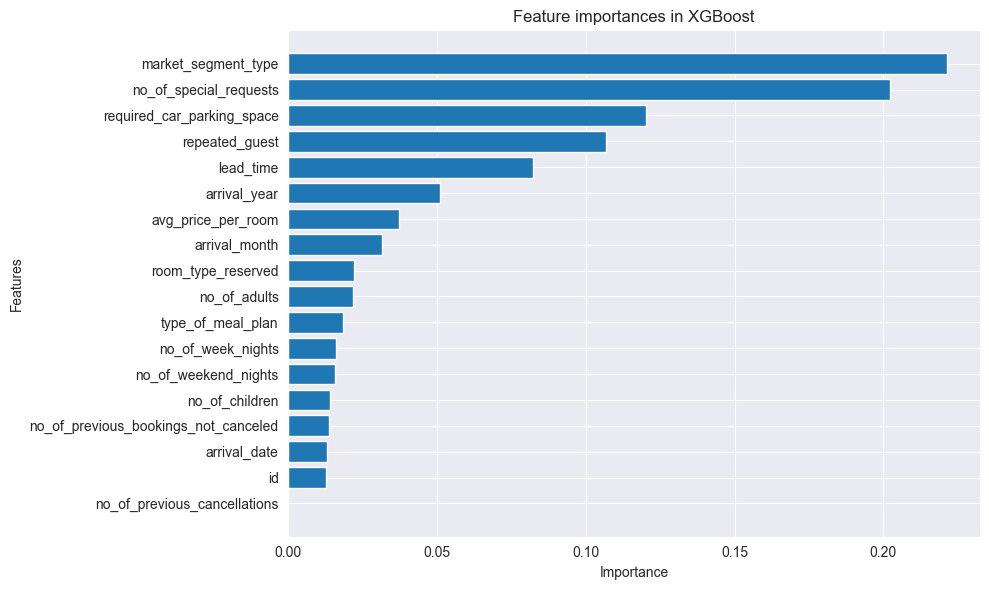

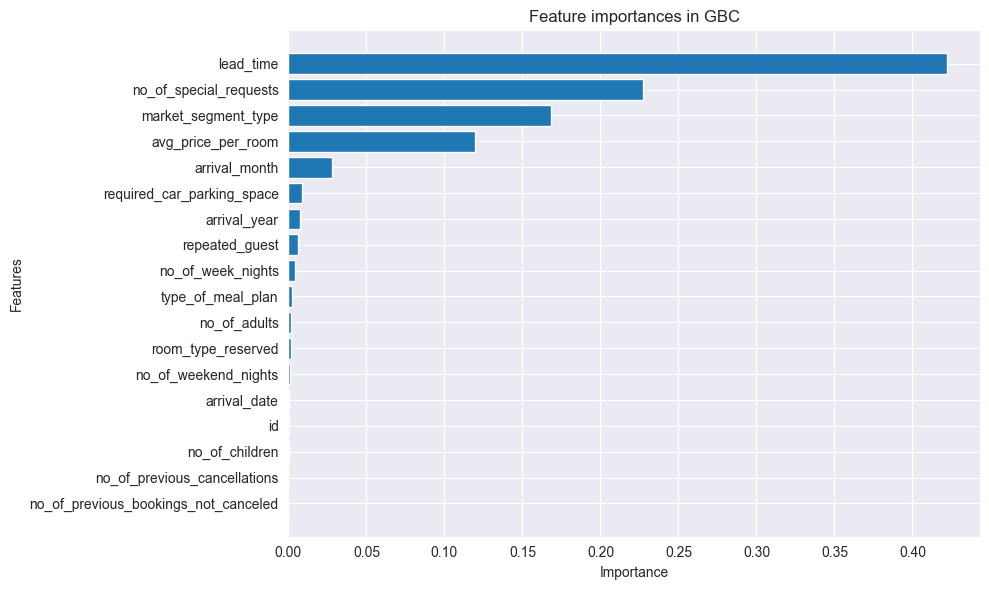

Answer choice: C


In [44]:
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost accuracy: {xgb_accuracy}")

xgb_feature_importances = xgb_model.feature_importances_
xgb_most_important_feature = X.columns[np.argmax(xgb_feature_importances)]
print(f"Most important feature in XGBoost: {xgb_most_important_feature}")

gbc_predictions = gbc_model.predict(X_test)
gbc_accuracy = accuracy_score(y_test, gbc_predictions)
print(f"GBC accuracy: {gbc_accuracy}")

gbc_feature_importances = gbc_model.feature_importances_
gbc_most_important_feature = X.columns[np.argmax(gbc_feature_importances)]
print(f"Most important feature in GBC: {gbc_most_important_feature}")

indices_xgb = np.argsort(xgb_feature_importances)
plt.figure(figsize=(10,6))
plt.title("Feature importances in XGBoost")
plt.barh(range(X_train.shape[1]), xgb_feature_importances[indices_xgb], align = "center")
plt.yticks(range(X_train.shape[1]), X.columns[indices_xgb])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

indices_gbc = np.argsort(gbc_feature_importances)
plt.figure(figsize=(10,6))
plt.title("Feature importances in GBC")
plt.barh(range(X_train.shape[1]), gbc_feature_importances[indices_gbc], align = "center")
plt.yticks(range(X_train.shape[1]), X.columns[indices_gbc])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

agree = (xgb_most_important_feature == gbc_most_important_feature)
if xgb_accuracy > gbc_accuracy:
    choice = "A" if agree else "C"
elif gbc_accuracy > xgb_accuracy:
    choice = "B" if agree else "D"
else:
    choice = "A" if agree else "C"
print("Answer choice:", choice)

## Matching Characteristics to XGBoost and LightGBM

Context:
Understanding the fundamental differences between boosting algorithms like XGBoost and LightGBM is crucial for making informed decisions about which to use based on the dataset characteristics. This task involves matching specific features of these models to their respective algorithms.

Task:
Correctly identify which characteristics apply to XGBoost and which apply to LightGBM.

Match the Following Characteristics
Models	Characteristics
A. XGBoost	I. Uses level-wise tree growth.
II. Uses leaf-wise tree growth.
B. LightGBM	III. Requires one-hot encoding for categorical features.
IV: Can handle categorical features natively without one-hot encoding.
Question:
Match the following characteristics to XGBoost and LightGBM:

Options:
A) [A — I, II] [B — III, IV]

B) [A — II, IV] [B — I, III]

C) [A — I, III] [B — II, IV (Correct)

D) [A — I, IV] [B — II, III]

## Comparing XGBoost and LightGBM

Context:
XGBoost and LightGBM are both popular gradient boosting frameworks that are widely used due to their performance and speed. Comparing these two models on the same dataset can provide valuable insights into their efficiency and effectiveness in predictive accuracy.

Task:
Train both XGBoost and LightGBM models using default parameters on the Reservation Booking Status dataset. Record and compare their training times and accuracies.

Instructions:
Prepare Data: Split the dataset into training and test sets using train_test_split, setting test_size to 0.2 and random_state to 10.
Train Models:
Train an XGBoost model and record the training time.
Train a LightGBM model and record the training time.
Evaluate Models: Measure the accuracy of each model on the test set.
Report Findings: Compare the training times and accuracies of XGBoost and LightGBM.
Question:
After training both models and evaluating them on the test set, which of the following statements is true?

In [48]:
from lightgbm import LGBMClassifier

start_time = time.time()
xgb_model = XGBClassifier(random_state = 10)
xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

start_time = time.time()
lgb_model = LGBMClassifier(random_state = 10)
lgb_model.fit(X_train, y_train)
lgb_train_time = time.time() - start_time
lgb_predictions = lgb_model.predict(X_test)
lgb_accuracy = accuracy_score(y_test, lgb_predictions)

print(f"XGBoost training time: {xgb_train_time} seconds")
print(f"XGBoost test accuracy: {xgb_accuracy}")
print(f"LightGBM training time: {lgb_train_time} seconds")
print(f"LightGBM test accuracy: {lgb_accuracy}")

[LightGBM] [Info] Number of positive: 13209, number of negative: 20471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 33680, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392191 -> initscore=-0.438111
[LightGBM] [Info] Start training from score -0.438111
XGBoost training time: 0.6568880081176758 seconds
XGBoost test accuracy: 0.8243467933491686
LightGBM training time: 1.8135721683502197 seconds
LightGBM test accuracy: 0.8184085510688837


## Comparing Stacking and Voting Ensemble Models

Context:
Stacking and voting are two ensemble techniques used to improve machine learning predictions by combining the strengths of multiple models. This task will explore their efficacy by using them in a classification problem with several popular algorithms as base learners.

Task:
Implement a stacking ensemble model and a voting ensemble model using the same base learners on the Reservation Booking Status dataset. Compare the accuracy of these two ensemble methods on the test set.

Instructions:
Load and Preprocess Data:

Ensure that the Reservation Booking Status dataset is clean and prepared for modeling.
Split the Data:

Use train_test_split to divide the data into training and test sets, ensuring random_state=10 for reproducibility.
Train Base Learners:

Initialize and train Random Forest, Gradient Boosting Classifier, XGBoost, LightGBM, and AdaBoost. Set random_state=10 where applicable to ensure consistent results.
Implement Stacking Ensemble:

Combine the predictions of the base learners to create a new training dataset for the meta-learner, XGBoost.
Train the XGBoost meta-learner on this new dataset.
Evaluate the stacking ensemble model on the test set.
Implement Voting Ensemble:

Combine the base learners using a voting mechanism.
Evaluate the voting ensemble model on the test set.
Compare Accuracies:

Determine which ensemble model performs better on the test set.
Question:
After implementing and evaluating both the stacking ensemble model with XGBoost as the meta-learner and the voting ensemble model, how do their accuracies compare on the test set?



In [50]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from mlxtend.classifier import StackingClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state = 10)
gbc = GradientBoostingClassifier(random_state = 10)
xgb = XGBClassifier(random_state = 10)
lgbm = LGBMClassifier(random_state = 10)
ada = AdaBoostClassifier(random_state = 10)

stacking_clf = StackingClassifier(
    classifiers = [rf, gbc, xgb, lgbm, ada],
    meta_classifier = XGBClassifier(random_state = 10),
    use_probas = True,
    average_probas = False
)

stacking_clf.fit(X_train, y_train)

stacking_predictions = stacking_clf.predict(X_test)
stacking_accuracy = accuracy_score(y_test, stacking_predictions)
print("---" * 10)
print(f"Stacking Model Accuracy: {stacking_accuracy}")
print("---" * 10)

voting_clf = VotingClassifier(estimators = [
    ('rf', rf), ('gbc', gbc), ('xgb', xgb), ('lgbm', lgbm), ('ada', ada)
])

voting_clf.fit(X_train, y_train)

voting_predictions = voting_clf.predict(X_test)
voting_accuracy = accuracy_score(y_test, voting_predictions)
print("---" * 10)
print(f"Voting Model Accuracy: {voting_accuracy}")

print("---" * 10)
if stacking_accuracy > voting_accuracy:
    print("Staking ensemble is more accurate.")
elif stacking_accuracy < voting_accuracy:
    print("Voting ensemble is more accurate.")
else:
    print("Both ensembles have the same accuracy")
print("---" * 10)

[LightGBM] [Info] Number of positive: 13209, number of negative: 20471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001778 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 33680, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392191 -> initscore=-0.438111
[LightGBM] [Info] Start training from score -0.438111
------------------------------
Stacking Model Accuracy: 0.8142517814726841
------------------------------
[LightGBM] [Info] Number of positive: 13209, number of negative: 20471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightG

## Implementing a Cascading Boosting Model

ontext:
Cascading models involve a sequential application of models where the output of one model feeds into the next. This technique can help focus a more complex model on the harder cases that a simpler model struggles with, potentially improving overall prediction accuracy.

Task:
Create a two-stage cascading boosting model where the first stage uses a LightGBM classifier to preprocess the data, and the second stage trains an XGBoost classifier on instances for which the first model had lower confidence. Evaluate the final model's performance on the entire test set.

Instructions:
Data Preparation:

Split the dataset into training and test sets using train_test_split with a test_size of 0.2 and random_state of 10.
First Stage - LightGBM Classifier:

Train a LightGBM classifier on the training set.
Obtain prediction probabilities for the training set and create a filter based on these probabilities (retain instances where the confidence is between 25% and 75%).
Second Stage - XGBoost Classifier:

Train an XGBoost classifier on the filtered training data.
Evaluate the classifier's performance on the entire test set using accuracy as the metric.
Question:
After implementing the cascading model where the first stage is a LightGBM classifier and the second stage is an XGBoost classifier trained on filtered instances, what is the accuracy of the final XGBoost model on the entire test set?

In [51]:
lgb_clf = LGBMClassifier(random_state = 10)
lgb_clf.fit(X_train, y_train)

lgb_train_prob = lgb_clf.predict_proba(X_train)[:, 1]
lgb_test_prob = lgb_clf.predict_proba(X_test)[:, 1]

filter_threshold = 0.75

filtered_train_df = X_train[(lgb_train_prob < filter_threshold) | (lgb_train_prob > (1-filter_threshold))]
filtered_y_train = y_train[(lgb_train_prob < filter_threshold) | (lgb_train_prob > (1-filter_threshold))]

xgb_clf = XGBClassifier(random_state = 10)
xgb_clf.fit(filtered_train_df, filtered_y_train)

final_predictions = xgb_clf.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)
print(f"Final Model Accuracy on Filtered Test Set: {final_accuracy}")

[LightGBM] [Info] Number of positive: 13209, number of negative: 20471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002799 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 33680, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392191 -> initscore=-0.438111
[LightGBM] [Info] Start training from score -0.438111
Final Model Accuracy on Filtered Test Set: 0.8243467933491686


## Matching Boosting Techniques

Context:
Boosting is a powerful ensemble technique that combines multiple weak learners to create a strong learner. Various boosting algorithms have unique characteristics that make them suitable for specific types of data or problems. This question aims to match each boosting technique with its defining feature.

Task:
Identify the unique specialty of each listed boosting technique based on its implementation details and typical use cases.

Boosting Techniques	Unique Specialties
1. Gradient Boosting	A. Utilizes gradient-based optimization and works with a variety of differentiable loss functions.
2. AdaBoost	B. Employs symmetric trees with a special scoring function that counteracts the bias in decision trees with respect to categorical features.
3. XGBoost	C. Introduces a regularization term in the objective function to control over-fitting, making it robust.
4. LightGBM	D. Utilizes a histogram-based algorithm that reduces memory usage and speeds up computation.
5. CatBoost	E. Uses an exponential loss function and focuses on reweighting misclassified instances after each iteration.
Question:
Match each boosting technique to the correct specialty that distinguishes it from the others, based on the description given.

Options:
A) [1 - A, 2 - E, 3 - C, 4 - D, 5 - B]

B) [1 - C, 2 - A, 3 - E, 4 - B, 5 - D]

C) [1 - D, 2 - B, 3 - A, 4 - E, 5 - C]

D) [1 - E, 2 - D, 3 - B, 4 - C, 5 - A]

## Stacking

Given the data (X and y), use sklearn's stacking for the regression model for firstly, training all the models individually, and then, training the stacked regressor.

In this question, we are using KNN and decision tree for the level 0 models and linear regression for the meta-model.

Note: All required dependencies have been imported already.

In [52]:
import numpy as np
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor

X - np.asarray(eval(input()))
y = np.asarray(eval(input()))

def get_stacking():
    level0 = list()
    level0.append(('knn', KNeighborsRegressor()))
    level0.append(('cart', DecisionTreeRegressor()))

    level1 = LinearRegression()

    model = StackingRegressor(estimators = level0, final_estimator = level1)

    return model

def get_model():
    models = dict()
    models['knn'] = KNeighborsRegressor()
    models['cart'] = DecisionTreeRegressor()
    models['stacking'] = get_stacking()
    return models

def evaluate_model(model, X, y):
    scores = cross_val_score(model, X, y, scoring='r2', cv = 5, n_jobs = 1)
    return scores

models = get_models()

results, names = list(), list()

for name, model in sorted(models.items()):
    scores = evaluate_model(model, X, y)
    results.append(scores)
    print('%s %.3f' % (name, np.mean(scores)))

SyntaxError: invalid syntax (<string>, line 2)